In [33]:
import numpy as np   
import pandas as pd
import scanpy as sc
import seaborn as sb
import matplotlib.pyplot as plt       
sc.settings.verbosity = 3           
sc.settings.set_figure_params(dpi=80, dpi_save=300, fontsize=8, figsize=(4,4), facecolor='white', transparent=True)

In [34]:
adata = sc.read_h5ad('Fibroblast_PCA_harmony.h5ad')

running Leiden clustering
    finished: found 14 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:17)


c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


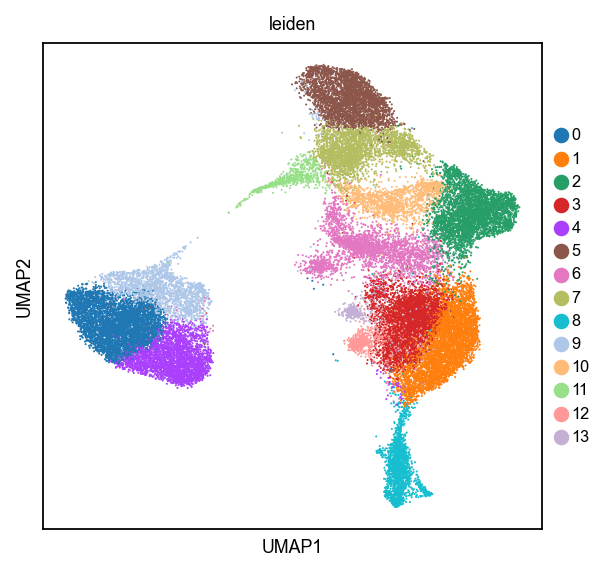

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


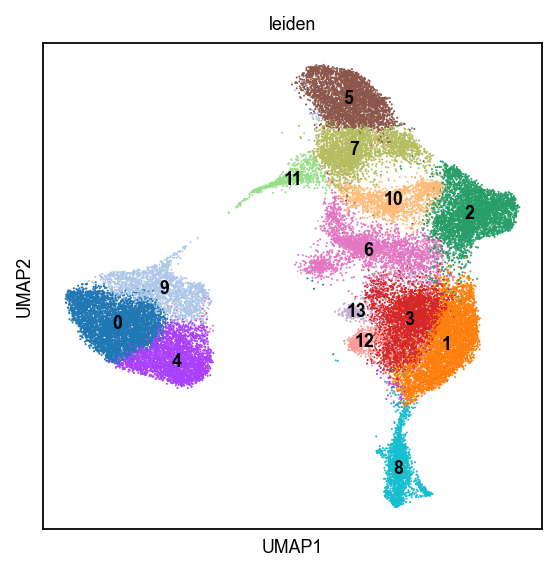

In [35]:
sc.tl.leiden(adata,resolution=1.2) 
sc.pl.umap(adata, color=['leiden'])
sc.pl.umap(adata, color=['leiden'],legend_loc='on data')

In [36]:
import scanpy as sc
import pandas as pd

groupby_key = "leiden"
reference = "rest"
method = "wilcoxon"
output_file = "DEG_leiden_result.xlsx"
sort_by = "logfoldchanges"
top_n = None

sc.tl.rank_genes_groups(
    adata,
    groupby=groupby_key,
    reference=reference,
    method=method
)

groups = adata.obs[groupby_key].astype(str).unique()

with pd.ExcelWriter(output_file) as writer:

    for g in groups:

        df = sc.get.rank_genes_groups_df(
            adata,
            group=g
        )

        if sort_by in df.columns:
            df = df.sort_values(by=sort_by, ascending=False)

        if top_n is not None:
            df = df.head(top_n)

        sheet_name = f"{groupby_key}_{g}"[:31]

        df.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Saved DEG results to: {output_file}")

ranking genes


c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchange

    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:02:23)
Saved DEG results to: DEG_leiden_result.xlsx


In [37]:
cluster2annotation2 = {
 '0': 'SOX6+',
 '1': 'SEPP1+',
 '2': 'C3+',
 '3': 'SEPP1+',
 '4': 'SOX6+',
 '5': 'PRKG1+',
 '6': 'Inflammatory',
 '7': 'PRKG1+',
 '8': 'Myofibroblast',
 '9': 'SOX6+',
 '10': 'C3+',
 '11': 'PRKG1+',
 '12': 'SEPP1+',
 '13': 'SEPP1+'
 }
adata.obs['cell type'] = adata.obs['leiden'].map(cluster2annotation2).astype('category')

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


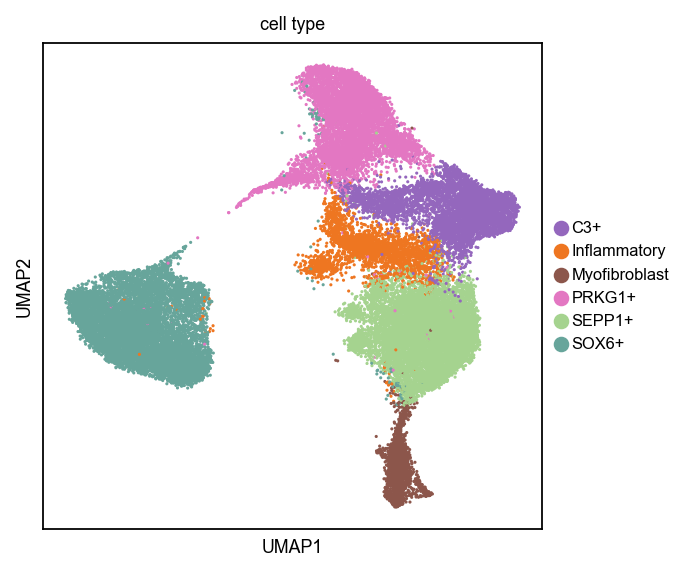

In [38]:
sc.pl.umap(adata , color=['cell type'], size=8,save="celltype.pdf")

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


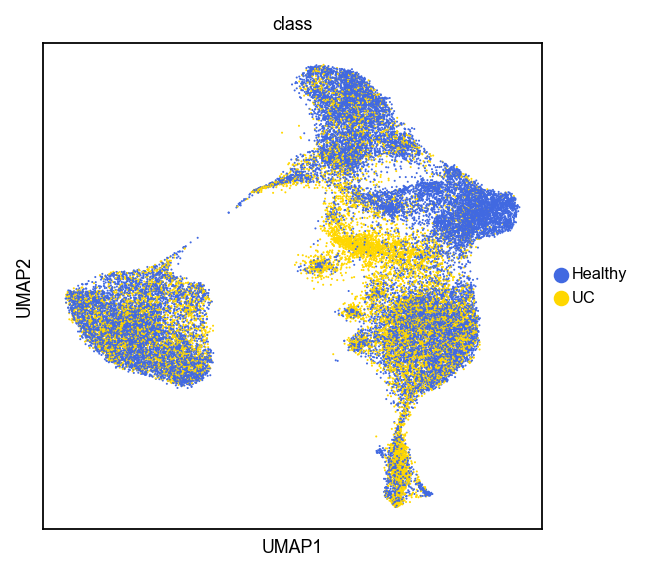

In [39]:
custom_palette = ['royalblue', 'gold'] 
adata.obs['class'] = adata.obs['class'].replace({
    'UC_inflamed': 'UC',     
})
sc.pl.umap(adata, color=['class'],palette=custom_palette,save='Healthy_UC_umap.pdf')

In [40]:
new_order = [
    "SOX6+",
    "PRKG1+",
    "C3+",
    "Myofibroblast",
    "SEPP1+",
     "Inflammatory",
]

adata.obs["cell type"] = adata.obs["cell type"].cat.reorder_categories(new_order)

In [41]:
marker_genes = [
    'PDGFRA', 'F3', 'FRZB', 'NSG1', 'NRG1', 'TRPA1', 'BMP5', 'COL4A6', 'ENHO', 'FGF9', 'WNT5B',
    'ABCA8', 'PRKG1', 'GPC6', 'EDIL3', 'PDE4D', 'ADAM28', 'FBXL7', 'MAPK10',  
    'C3', 'C7', 'IGF1', 'GPNMB', 'PRELP', 'TNXB', 'FBLN2', 'SFRP2', 'SFRP1', 
    'ACTA2', 'TAGLN', 'ACTG2', 'TPM1', 'MYL9', 'HHIP', 'PDLIM3', 'MYH11', 'MYLK',
    'SEPP1', 'IGHA1', 'SELM', 'ATP5E', 'PPAP2B', 'GNB2L1',
     'MMP1', 'CXCL1', 'PDPN', 'FAP', 'HIF1A', 'TGFBI', 'CXCL3', 'CHI3L1',
]

In [42]:
adata.obs['cell type'].cat.categories

Index(['SOX6+', 'PRKG1+', 'C3+', 'Myofibroblast', 'SEPP1+', 'Inflammatory'], dtype='object')

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


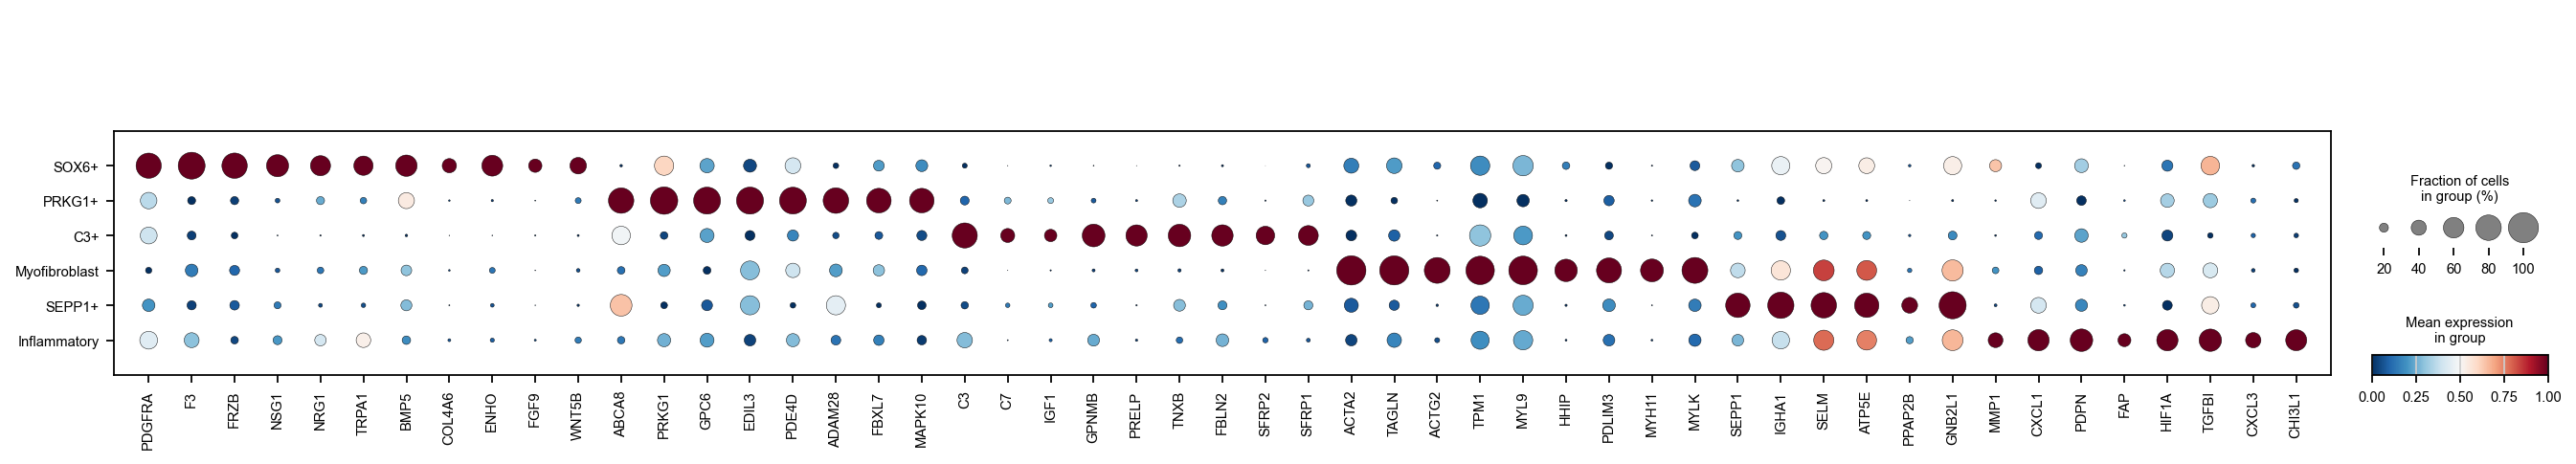

In [43]:
ax = sc.pl.dotplot(adata, marker_genes, groupby='cell type',
                     swap_axes=False,dot_max=None,
                   dot_min=None, standard_scale="var", cmap='RdBu_r')

In [44]:
import matplotlib.pyplot as plt

cats = adata.obs["cell type"].cat.categories

colors = plt.cm.tab20.colors[:len(cats)]

adata.uns["cell type_colors"] = colors

In [45]:
celltype_color_map = {
    "SOX6+": "#8c564b",
    "PRKG1+": "#9467bd",
    "C3+": "#EE7621",
    "Myofibroblast": "#A5D38F",
    "SEPP1+": "#67A59B",
    "Inflammatory": "#e377c2"
}

adata.uns["cell type_colors"] = [
    celltype_color_map[x] for x in adata.obs["cell type"].cat.categories
]

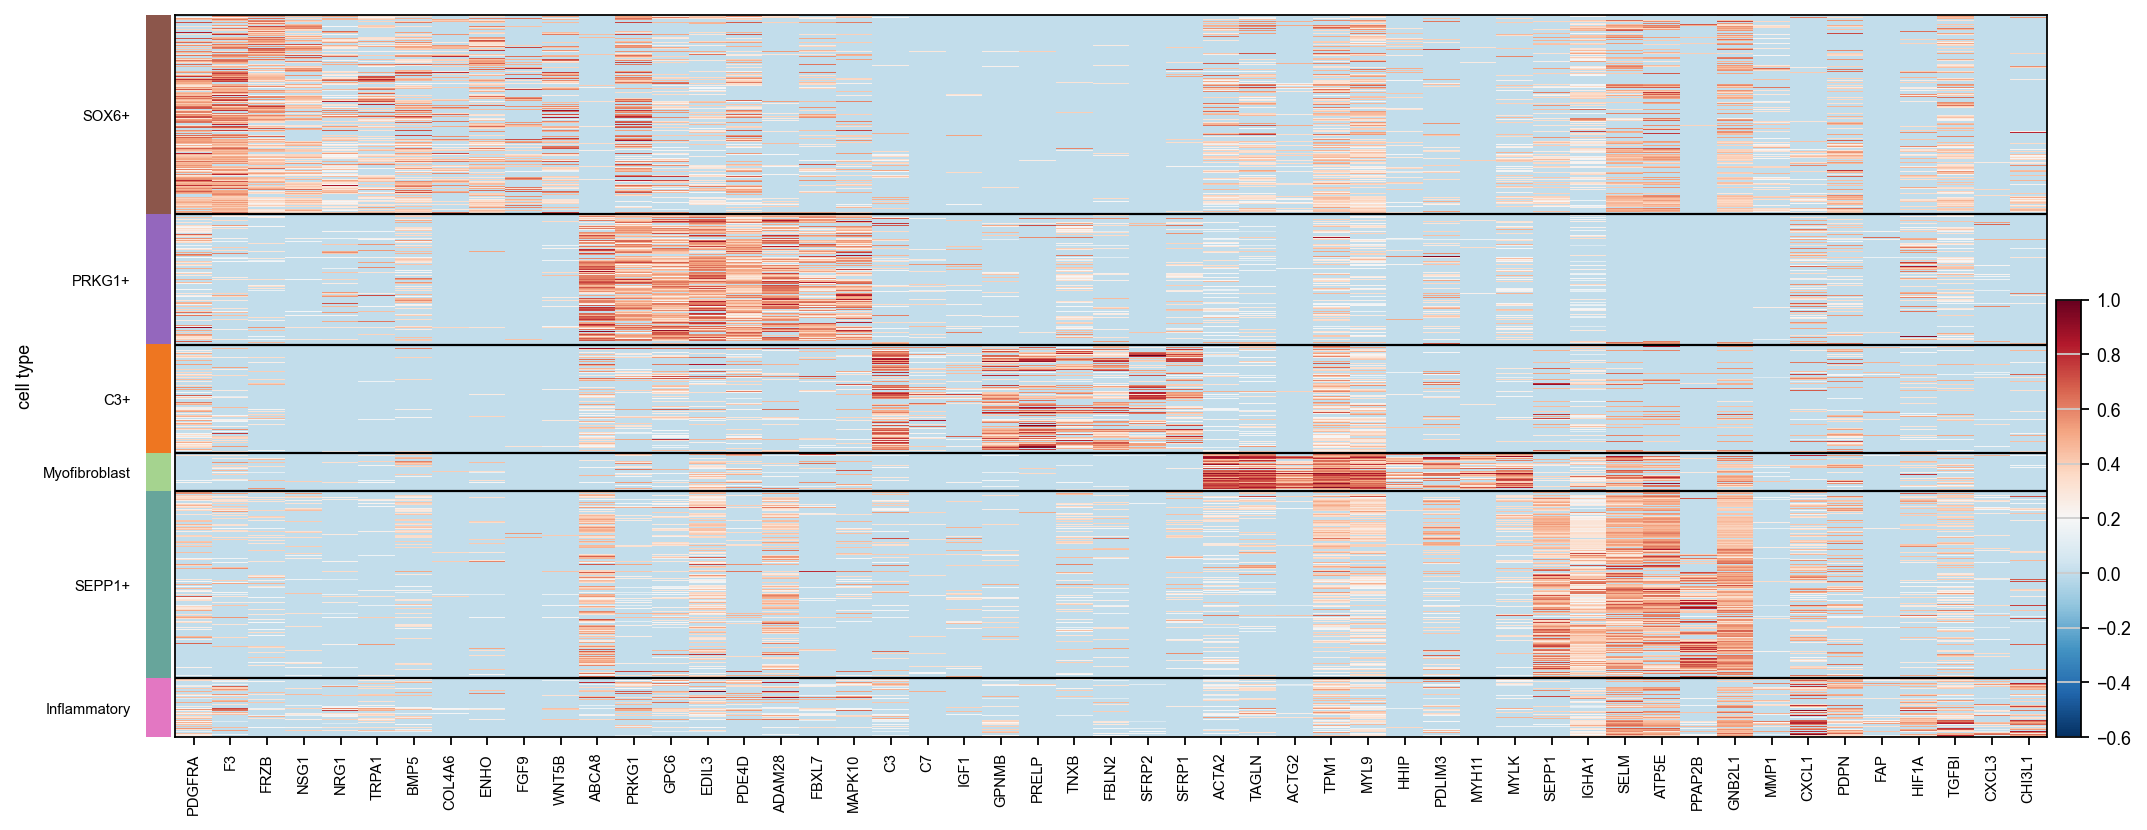

In [46]:
ax = sc.pl.heatmap(adata, marker_genes, groupby='cell type',cmap='RdBu_r',
                    show_gene_labels=True,
                    var_group_rotation=45, 
                    standard_scale="var",
                    vmin=-0.6,
                      vmax=1,save="marker_gene"
                       )

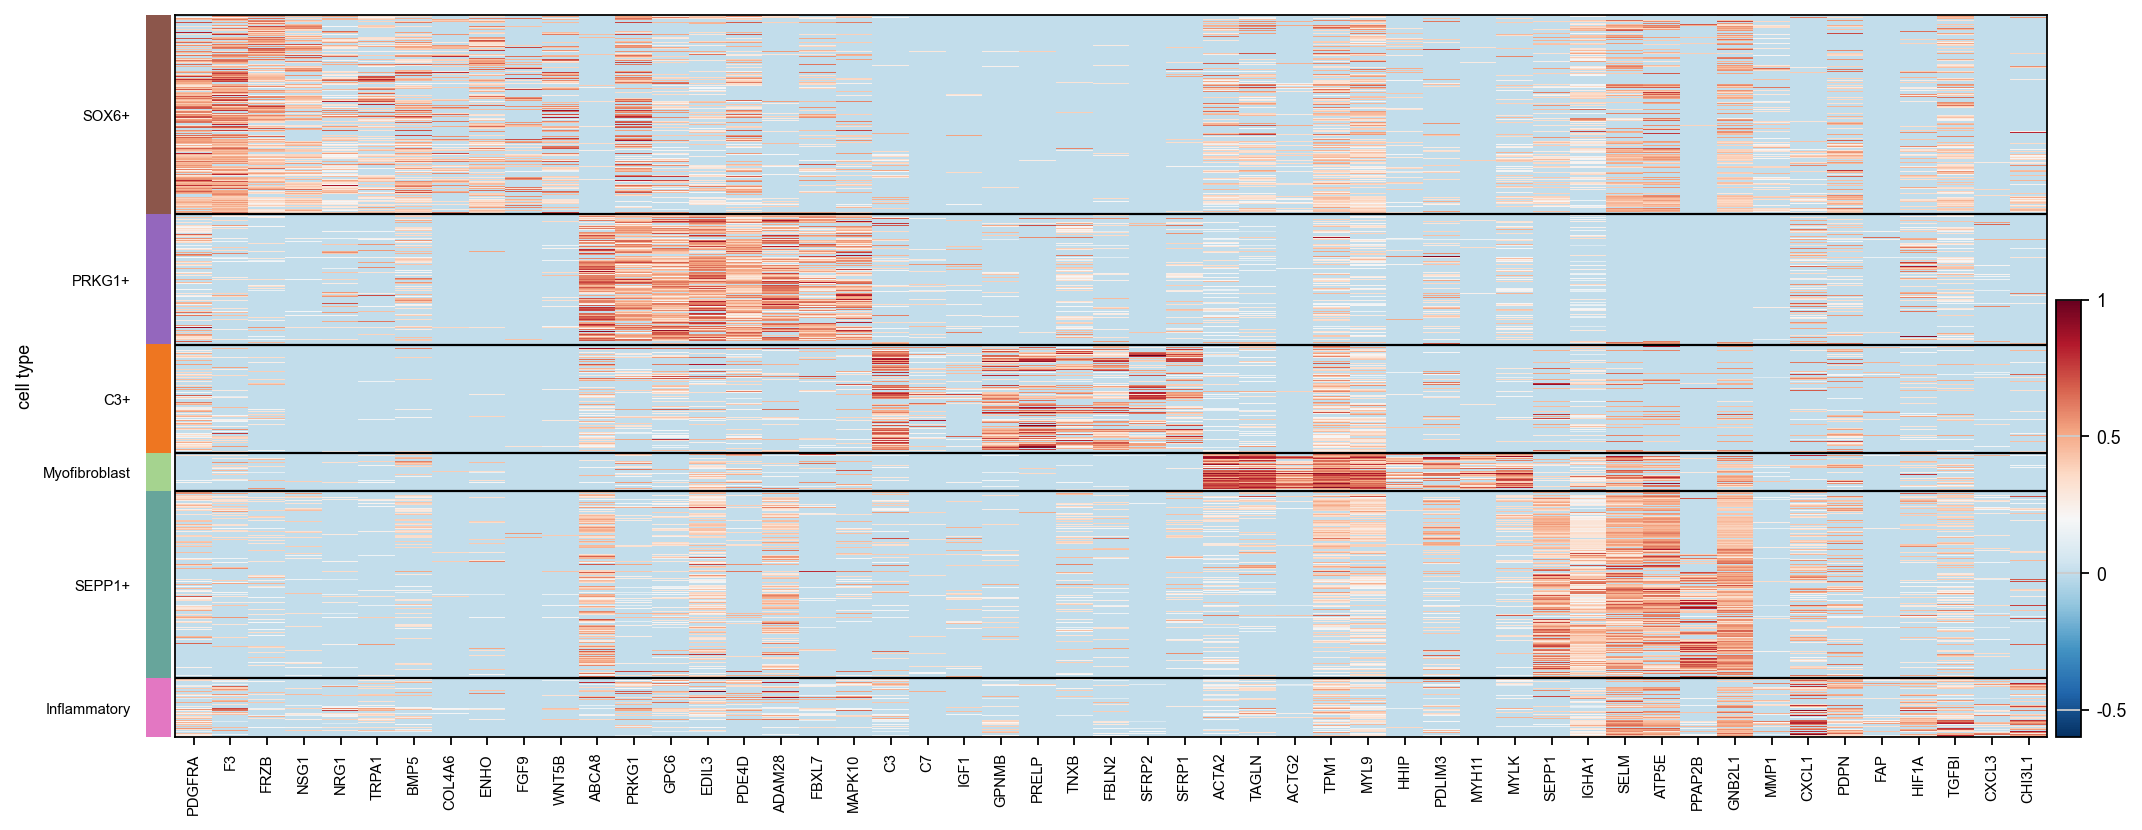

In [47]:
import matplotlib.pyplot as plt

ax = sc.pl.heatmap(
    adata,
    marker_genes,
    groupby='cell type',
    cmap='RdBu_r',
    show_gene_labels=True,
    var_group_rotation=45,
    standard_scale="var",
    vmin=-0.6,
    vmax=1,
    show=False
)


heatmap_ax = ax["heatmap_ax"]


cbar = heatmap_ax.images[0].colorbar


cbar.set_ticks([-0.5, 0, 0.5,1])
cbar.ax.set_yticklabels(["-0.5", "0", "0.5","1"])

plt.show()

In [48]:
new_order = [
    "SOX6+",
    "SEPP1+",
    "PRKG1+",
    "C3+",
    "Inflammatory",
    "Myofibroblast"
]

adata.obs["cell type"] = adata.obs["cell type"].cat.reorder_categories(new_order)

In [49]:
custom_palette = ['#8c564b','#67A59B',  '#9467bd','#EE7621',  '#e377c2', '#A5D38F',]

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list


c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


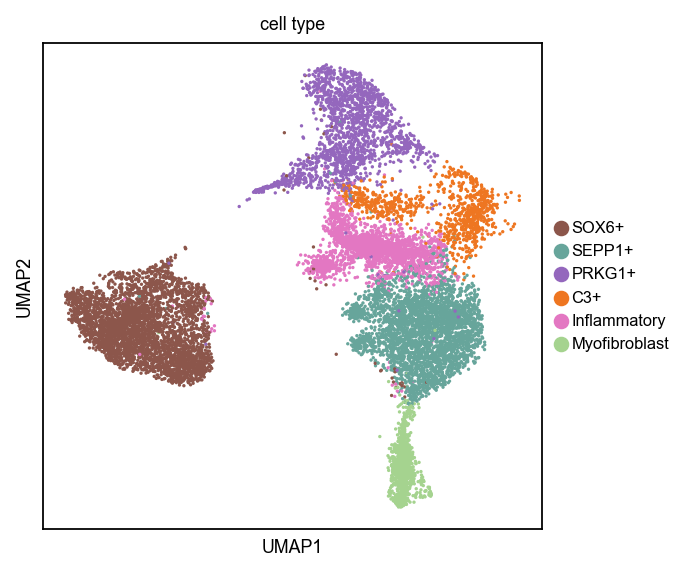

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list


c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


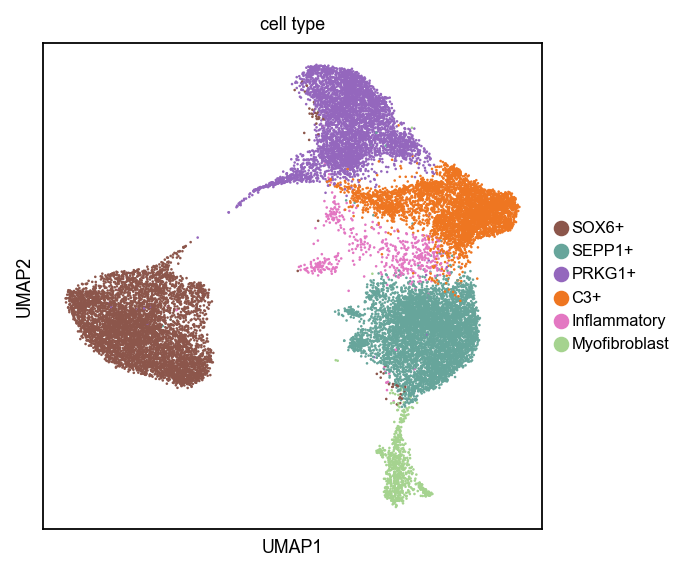

In [50]:
adataUC = adata[adata.obs['class'] == 'UC']
adataHealthy = adata[adata.obs['class'] == 'Healthy']
sc.pl.umap(adataUC, palette=custom_palette, color=['cell type'],save="UC")
sc.pl.umap(adataHealthy, palette=custom_palette,color=['cell type'],save="Healthy")

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


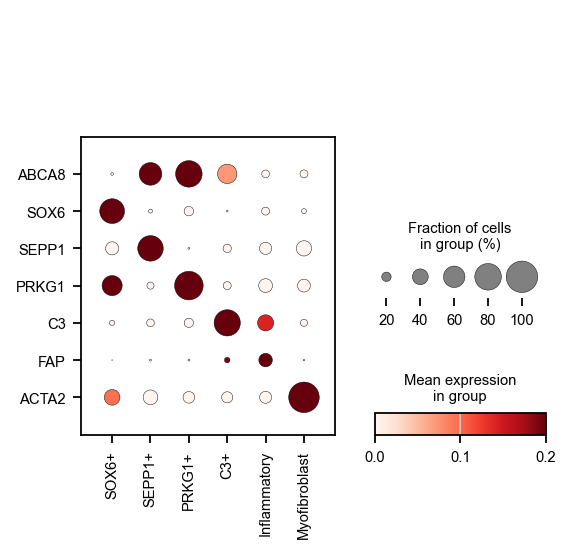

In [51]:
sc.pl.dotplot(adata, ['ABCA8','SOX6','SEPP1','PRKG1','C3','FAP','ACTA2'], 
              groupby='cell type',
              vmax=0.2,vmin=0,
              swap_axes=True,
              save="celltype_dotplot.pdf")

C:\Users\wangqiang\AppData\Local\Temp\ipykernel_34308\1000138696.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


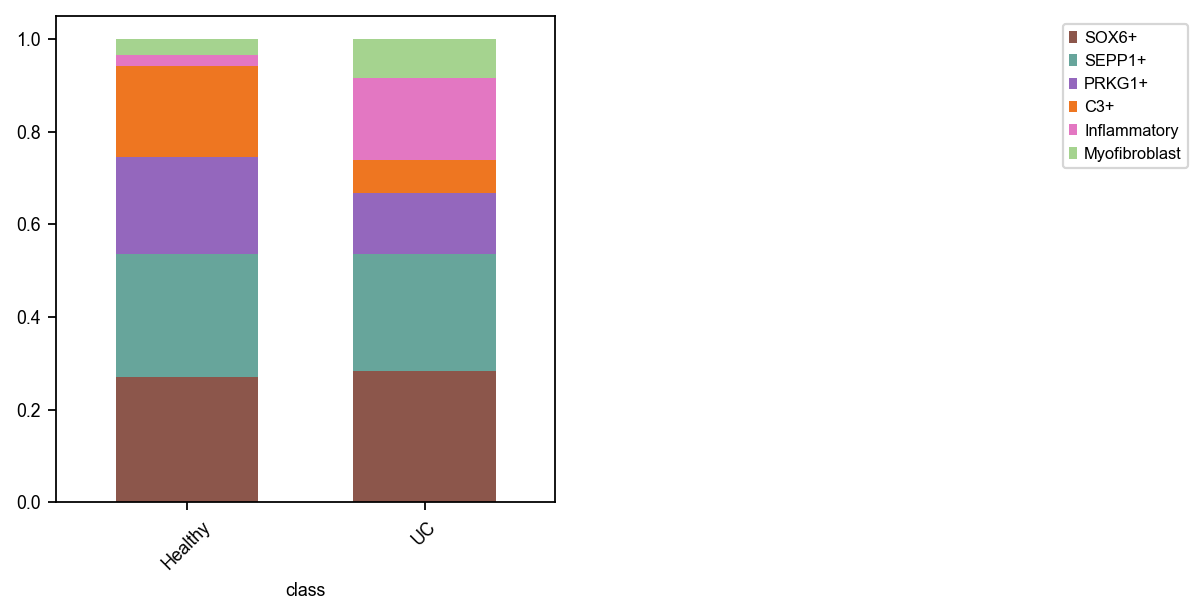

In [52]:
order = [ 'SOX6+','SEPP1+',
          'PRKG1+','C3+','Inflammatory',
         'Myofibroblast']  
adata.obs['cell type'] = pd.Categorical(adata.obs['cell type'], categories=order, ordered=True)

colors = ['#8c564b','#67A59B',  '#9467bd','#EE7621',  '#e377c2', '#A5D38F',]
tmp = pd.crosstab(adata.obs['class'], adata.obs['cell type'],normalize='index')
ax = tmp.plot.bar(stacked=True, width=0.6,color=colors, edgecolor='none') 

ax.legend(loc='upper left', bbox_to_anchor=(2, 1))


ax.grid(False) 


plt.tight_layout()
plt.xticks(rotation=45)

plt.savefig('crosstab.pdf')

plt.show()

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


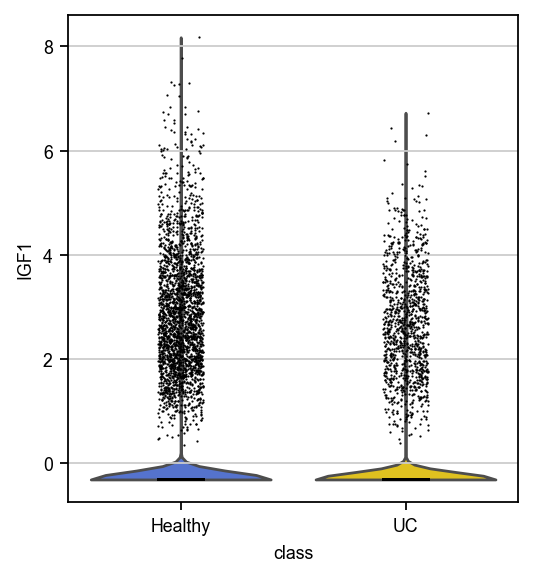

In [53]:
sc.pl.violin(adata, 'IGF1', groupby='class')

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


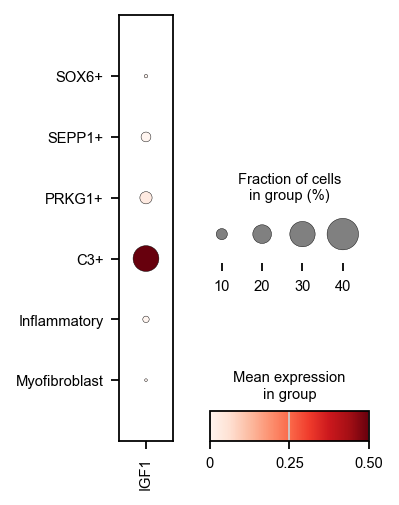

In [54]:
import matplotlib.pyplot as plt

dp = sc.pl.dotplot(
    adata,
    ['IGF1'],
    groupby='cell type',
    figsize=(2,3.5),
    vmin=0,
    vmax=0.5,
    return_fig=True,
    show=False
)

cbar = dp.get_axes()['color_legend_ax']
cbar.set_xticks([0, 0.25, 0.50])
cbar.set_xticklabels(['0', '0.25', '0.50'])


dp.fig.canvas.draw()

plt.savefig(
    "IGF1DOT.pdf",
    bbox_inches="tight"
)

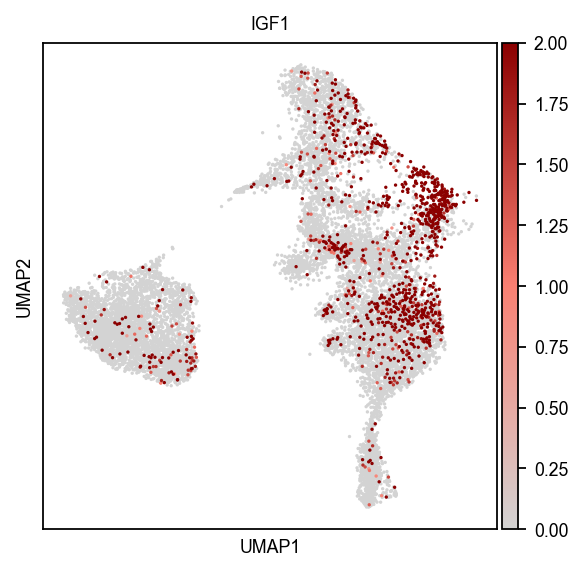

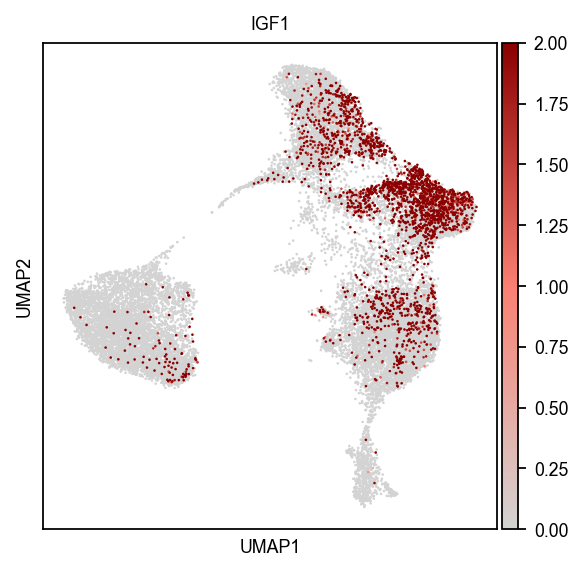

In [55]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

colors = ["lightgrey", "Salmon", "#8B0000"]
custom_cmap = LinearSegmentedColormap.from_list("grey_to_red", colors)


sc.pl.umap(adataUC, color=['IGF1'],cmap=custom_cmap,vmax=2,vmin='0',save="UC_IGF1_UMAP.pdf")
sc.pl.umap(adataHealthy, color=['IGF1'],cmap=custom_cmap,vmax=2,vmin='0',save="Healthy_IGF1_UMAP.pdf")

In [56]:
adata.write_h5ad(
"Fibroblast_annotation.h5ad",compression="gzip"
)

In [57]:
import scanpy as sc
import pandas as pd


groupby_key = "cell type"
target_group = "C3+"
reference_group = "rest"
method = "wilcoxon"

output_file = "DEG_C3.csv"


sc.tl.rank_genes_groups(
    adata,
    groupby=groupby_key,
    groups=[target_group],
    reference=reference_group,
    method=method
)


names = adata.uns['rank_genes_groups']['names'][target_group]

logfc = adata.uns['rank_genes_groups']['logfoldchanges'][target_group]

scores = adata.uns['rank_genes_groups']['scores'][target_group]

pvals = adata.uns['rank_genes_groups']['pvals'][target_group]

pvals_adj = adata.uns['rank_genes_groups']['pvals_adj'][target_group]


df = pd.DataFrame({
    'gene': names,
    'log2FC': logfc,
    'scores': scores,
    'p_value': pvals,
    'p_adj': pvals_adj
})


df.to_csv(output_file, index=False)

print(f"Saved: {output_file}")

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:01:10)
Saved: DEG_C3.csv


c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
